In [1]:
import pypsa
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import json, hashlib

In [2]:
# for p in Path("/home/sammy").rglob("base_s_25_elec_.nc"):
#     print(p)

In [3]:
network_path = Path("/home/sammy/pypsa-eur/results/se-de-dk-elec-2019-daily/networks/base_s_25_elec_.nc")

print(network_path.exists())

net_df = pypsa.Network(network_path)
n = net_df

True


INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [4]:
net_df


PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 75
 - Carrier: 25
 - Generator: 210
 - GlobalConstraint: 1
 - Line: 48
 - Link: 123
 - Load: 25
 - StorageUnit: 46
 - Store: 50
 - SubNetwork: 2
Snapshots: 364

In [5]:
net_df.storage_units.carrier.value_counts()

carrier
battery    25
PHS        16
hydro       5
Name: count, dtype: int64

In [6]:
net_df.generators.carrier.value_counts()


carrier
coal             46
biomass          25
ror              22
CCGT             21
oil              18
onwind           13
solar-hsat       13
solar            13
offwind-ac       10
offwind-dc       10
offwind-float    10
lignite           6
nuclear           2
OCGT              1
Name: count, dtype: int64

SOME SANITY CHECKS AFTER LOADING THE NETWORK

In [7]:
print("Snapshots:", len(n.snapshots))
print("Snapshot start/end:", n.snapshots[0], "→", n.snapshots[-1])

print("\nComponents:")
print("Buses:", len(n.buses))
print("Lines:", len(n.lines))
print("Links:", len(n.links))
print("Generators:", len(n.generators))
print("Loads:", len(n.loads))
print("Stores:", len(n.stores))
print("StorageUnits:", len(n.storage_units))

Snapshots: 364
Snapshot start/end: 2019-01-01 00:00:00 → 2019-12-30 00:00:00

Components:
Buses: 75
Lines: 48
Links: 123
Generators: 210
Loads: 25
Stores: 50
StorageUnits: 46


Is the model solved?

In [ ]:
# to be sure of the onbjective, I will check if it is there or not then we move
print("Objective :", getattr(n, "objective", None))

# Now, i want to check if there are duals/marginal prices (sign of solved optimization:  Happy me, optimal solution found. If not I will be sad)
has_prices = hasattr(n, "buses_t") and hasattr(n.buses_t, "marginal_price") and not n.buses_t.marginal_price.empty
print("Has marginal prices:", has_prices)

Objective : 5713317306.716583
Has marginal prices: True


Let us Confirm geography: are SWEDEN, GERMANY AND DENMARK really present?

In [ ]:
# Lets try by country tag in buses
if 'country' in n.buses.columns:
    print(n.buses['country'].value_counts().head(20))
    print("\nCountries present (unique):", sorted(n.buses['country'].dropna().unique())[:30])
else:
    print("'country' column not found in n.buses. Available columns:", list(n.buses.columns))

country
DE    54
SE    15
DK     6
Name: count, dtype: int64

Countries present (unique): ['DE', 'DK', 'SE']


Identifying what technologies exist (a.k.a carriers)

In [10]:
def top_counts(df, col, n=30):
    if col in df.columns:
        return df[col].value_counts().head(n)
    return None

print("\nGenerator carriers (top):")
print(top_counts(n.generators, "carrier", 40))

print("\nLink carriers (top):")
print(top_counts(n.links, "carrier", 40))

print("\nStorageUnit carriers (top):")
print(top_counts(n.storage_units, "carrier", 40))

print("\nStore carriers (top):")
print(top_counts(n.stores, "carrier", 40))


Generator carriers (top):
carrier
coal             46
biomass          25
ror              22
CCGT             21
oil              18
onwind           13
solar-hsat       13
solar            13
offwind-ac       10
offwind-dc       10
offwind-float    10
lignite           6
nuclear           2
OCGT              1
Name: count, dtype: int64

Link carriers (top):
carrier
H2 electrolysis       25
H2 fuel cell          25
battery charger       25
battery discharger    25
DC                    23
Name: count, dtype: int64

StorageUnit carriers (top):
carrier
battery    25
PHS        16
hydro       5
Name: count, dtype: int64

Store carriers (top):
carrier
H2         25
battery    25
Name: count, dtype: int64


Now the question  “is the annual energy balance sane?” 

In [11]:
# Load time series
load = n.loads_t.p_set.sum(axis=1) if hasattr(n, "loads_t") and hasattr(n.loads_t, "p_set") else None

# Generator dispatch
gen = n.generators_t.p.sum(axis=1) if hasattr(n, "generators_t") and hasattr(n.generators_t, "p") else None

print("Has load series:", load is not None)
print("Has generator dispatch:", gen is not None)

if load is not None and gen is not None:
    print("\nTotal load (TWh):", load.sum()/1e6)
    print("Total generator output (TWh):", gen.sum()/1e6)
    print("Mean hourly load (GW):", load.mean()/1e3)

Has load series: True
Has generator dispatch: True

Total load (TWh): 27.43024854356416
Total generator output (TWh): 25.417107241385178
Mean hourly load (GW): 75.35782566913232


SYSTEM OVERVIEW PLOTS

TECHNOLOGY STRUCTURE & UTILISATION

What is the Installed capacity mix (what the system owns) ?

In [12]:
installed_capacity = (
    n.generators
    .groupby("carrier")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
)

installed_capacity_GW = installed_capacity / 1e3
installed_capacity_GW

carrier
onwind           81.678938
solar            80.168199
solar-hsat       36.836346
CCGT             29.451883
lignite          21.701743
coal             21.182463
offwind-ac       12.516600
nuclear           8.617000
ror               6.038231
biomass           3.793507
oil               2.663108
OCGT              0.023310
offwind-dc        0.000000
offwind-float     0.000000
Name: p_nom_opt, dtype: float64

What is the Annual energy mix (what actually runs/ Actual energy production)

In [13]:
annual_energy = (
    n.generators_t.p
    .T
    .groupby(n.generators.carrier)
    .sum()
    .T
    .sum()
)

annual_energy_TWh = annual_energy / 1e6
annual_energy_TWh

carrier
CCGT             0.048712
OCGT             0.000000
biomass          1.125477
coal             0.600061
lignite          3.307898
nuclear          2.240837
offwind-ac       2.309062
offwind-dc       0.000000
offwind-float    0.000000
oil              0.000000
onwind           9.193346
ror              1.078209
solar            3.503175
solar-hsat       2.010330
dtype: float64

In [14]:
hours = len(n.snapshots)

capacity_factor = (
    annual_energy
    / (installed_capacity * hours)
).sort_values(ascending=False)

capacity_factor

carrier
biomass          0.815069
nuclear          0.714419
offwind-ac       0.506813
ror              0.490560
lignite          0.418751
onwind           0.309216
solar-hsat       0.149930
solar            0.120049
coal             0.077825
CCGT             0.004544
OCGT             0.000000
oil              0.000000
offwind-dc            NaN
offwind-float         NaN
dtype: float64

In [15]:
tech_summary = pd.DataFrame({
    "Installed capacity (GW)": installed_capacity_GW,
    "Annual energy (TWh)": annual_energy_TWh,
    "Capacity factor": capacity_factor
}).sort_values("Installed capacity (GW)", ascending=False)

tech_summary

,Installed capacity (GW),Annual energy (TWh),Capacity factor
carrier,,,
onwind,81.678938,9.193346,0.309216
solar,80.168199,3.503175,0.120049
solar-hsat,36.836346,2.010330,0.149930
CCGT,29.451883,0.048712,0.004544
lignite,21.701743,3.307898,0.418751
coal,21.182463,0.600061,0.077825
offwind-ac,12.516600,2.309062,0.506813
nuclear,8.617000,2.240837,0.714419
ror,6.038231,1.078209,0.490560


The installed capacity structure of the electricity system is dominated by variable renewable energy sources, in particular onshore wind and solar photovoltaics, which together account for the majority of total nameplate capacity. However, their contribution to annual electricity generation is substantially lower than their capacity share, reflecting limited capacity factors driven by weather dependence and seasonal availability. Onshore wind exhibits a moderate capacity factor of approximately 31%, while solar technologies operate at even lower utilisation levels of around 12–15%. Offshore wind shows markedly higher utilisation, with capacity factors exceeding 50%, highlighting its comparatively stable production profile and higher system value. These contrasts demonstrate that capacity expansion alone is not a sufficient indicator of effective energy supply, particularly in systems with high shares of variable renewables.

In contrast, dispatchable and low-variability technologies such as nuclear, biomass, and run-of-river hydropower deliver a disproportionate share of total electricity relative to their installed capacity. Biomass and nuclear plants operate at high capacity factors exceeding 70%, underscoring their role as firm, system-stabilising generation. Fossil thermal technologies, particularly gas-fired and oil-based units, exhibit extremely low utilisation despite substantial installed capacity, indicating that they function primarily as reliability and adequacy resources rather than energy suppliers. Coal and lignite show divergent behaviour, with lignite operating at relatively high capacity factors while coal remains largely marginal. Overall, the comparison between installed capacity, realised energy production, and utilisation rates reveals a system in which variable renewables shape capacity requirements and price volatility, while dispatchable technologies provide firmness and risk mitigation, an asymmetry that strongly motivates the subsequent use of stochastic modelling to capture uncertainty in weather-driven generation and system stress conditions.

In [16]:
tech_colors = {
    # Low-carbon / renewables
    "nuclear": "#4daf4a",        # green – baseload, low variability
    "biomass": "#ff7f00",        # orange – dispatchable renewable
    "ror": "#1f78b4",             # blue – run-of-river hydro

    "solar": "#ffd92f",          # yellow
    "solar-hsat": "#66c2a5",     # teal

    "onwind": "#999999",         # grey
    "offwind-ac": "#e41a1c",     # red
    "offwind-dc": "#984ea3",     # purple
    "offwind-float": "#a65628",  # brown

    # Fossil thermal
    "CCGT": "#377eb8",           # blue – flexible gas
    "OCGT": "#a6cee3",           # light blue – peaking gas
    "coal": "#4d4d4d",           # dark grey
    "lignite": "#8c510a",        # brownish – high carbon
    "oil": "#f781bf"             # pink – emergency / legacy
}

PLOTS

Capacity vs Energy

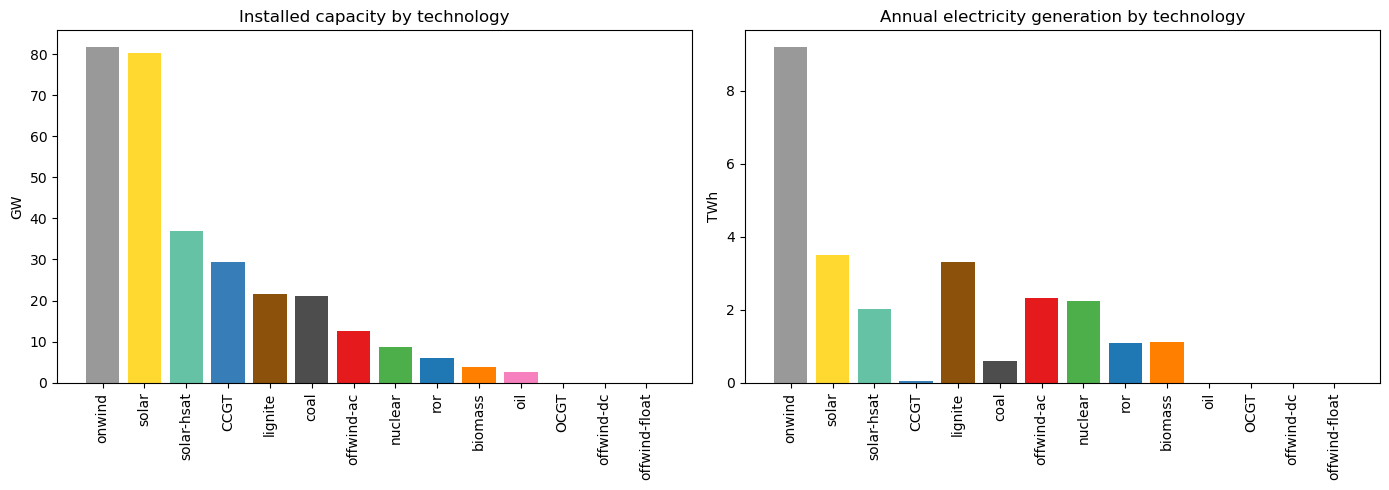

In [17]:
# Ensure consistent ordering
techs = tech_summary.index

colors = [tech_colors.get(t, "black") for t in techs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Installed capacity
axes[0].bar(
    techs,
    tech_summary["Installed capacity (GW)"],
    color=colors
)
axes[0].set_title("Installed capacity by technology")
axes[0].set_ylabel("GW")
axes[0].tick_params(axis="x", rotation=90)

# Annual energy
axes[1].bar(
    techs,
    tech_summary["Annual energy (TWh)"],
    color=colors
)
axes[1].set_title("Annual electricity generation by technology")
axes[1].set_ylabel("TWh")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [18]:
def plot_capacity_vs_energy_by_country(
    n,
    tech_summary,
    tech_colors,
    mode="COMBINED",        # "COMBINED", "SELECT", "ALL"
    countries=None          # e.g. ["SE", "DE", "DK"]
):
    assert mode in ["COMBINED", "SELECT", "ALL"]

    # Generator table with country info
    gen = n.generators.copy()
    gen["country"] = n.buses.loc[gen.bus, "country"].values

    dispatch = n.generators_t.p
    hours = len(n.snapshots)

    # Decide countries to loop over
    if mode == "COMBINED":
        country_list = ["ALL"]

    elif mode == "SELECT":
        assert countries is not None, "Provide countries for SELECT mode"
        country_list = ["+".join(countries)]

    elif mode == "ALL":
        country_list = sorted(gen.country.dropna().unique())

    techs = tech_summary.index
    colors = [tech_colors.get(t, "black") for t in techs]

    # Prepare figure
    nrows = len(country_list)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=2,
        figsize=(14, 4 * nrows),
        sharex=True,
        sharey=False
    )

    if nrows == 1:
        axes = [axes]

    # Loop over countries
    for i, country in enumerate(country_list):

        if country == "ALL":
            idx = gen.index

        elif mode == "SELECT":
            idx = gen.index[gen.country.isin(countries)]

        else:
            idx = gen.index[gen.country == country]

        # Installed capacity
        cap = (
            gen.loc[idx]
            .groupby("carrier")["p_nom_opt"]
            .sum()
            .reindex(techs, fill_value=0)
            / 1e3
        )

        # Annual energy
        energy = (
            dispatch[idx]
            .T
            .groupby(gen.loc[idx, "carrier"])
            .sum()
            .T
            .sum()
            .reindex(techs, fill_value=0)
            / 1e6
        )

        # Plot capacity
        axes[i][0].bar(techs, cap, color=colors)
        axes[i][0].set_ylabel("GW")
        axes[i][0].set_title(f"{country} – Installed capacity")

        # Plot energy
        axes[i][1].bar(techs, energy, color=colors)
        axes[i][1].set_ylabel("TWh")
        axes[i][1].set_title(f"{country} – Annual energy")

        axes[i][0].tick_params(axis="x", rotation=90)
        axes[i][1].tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

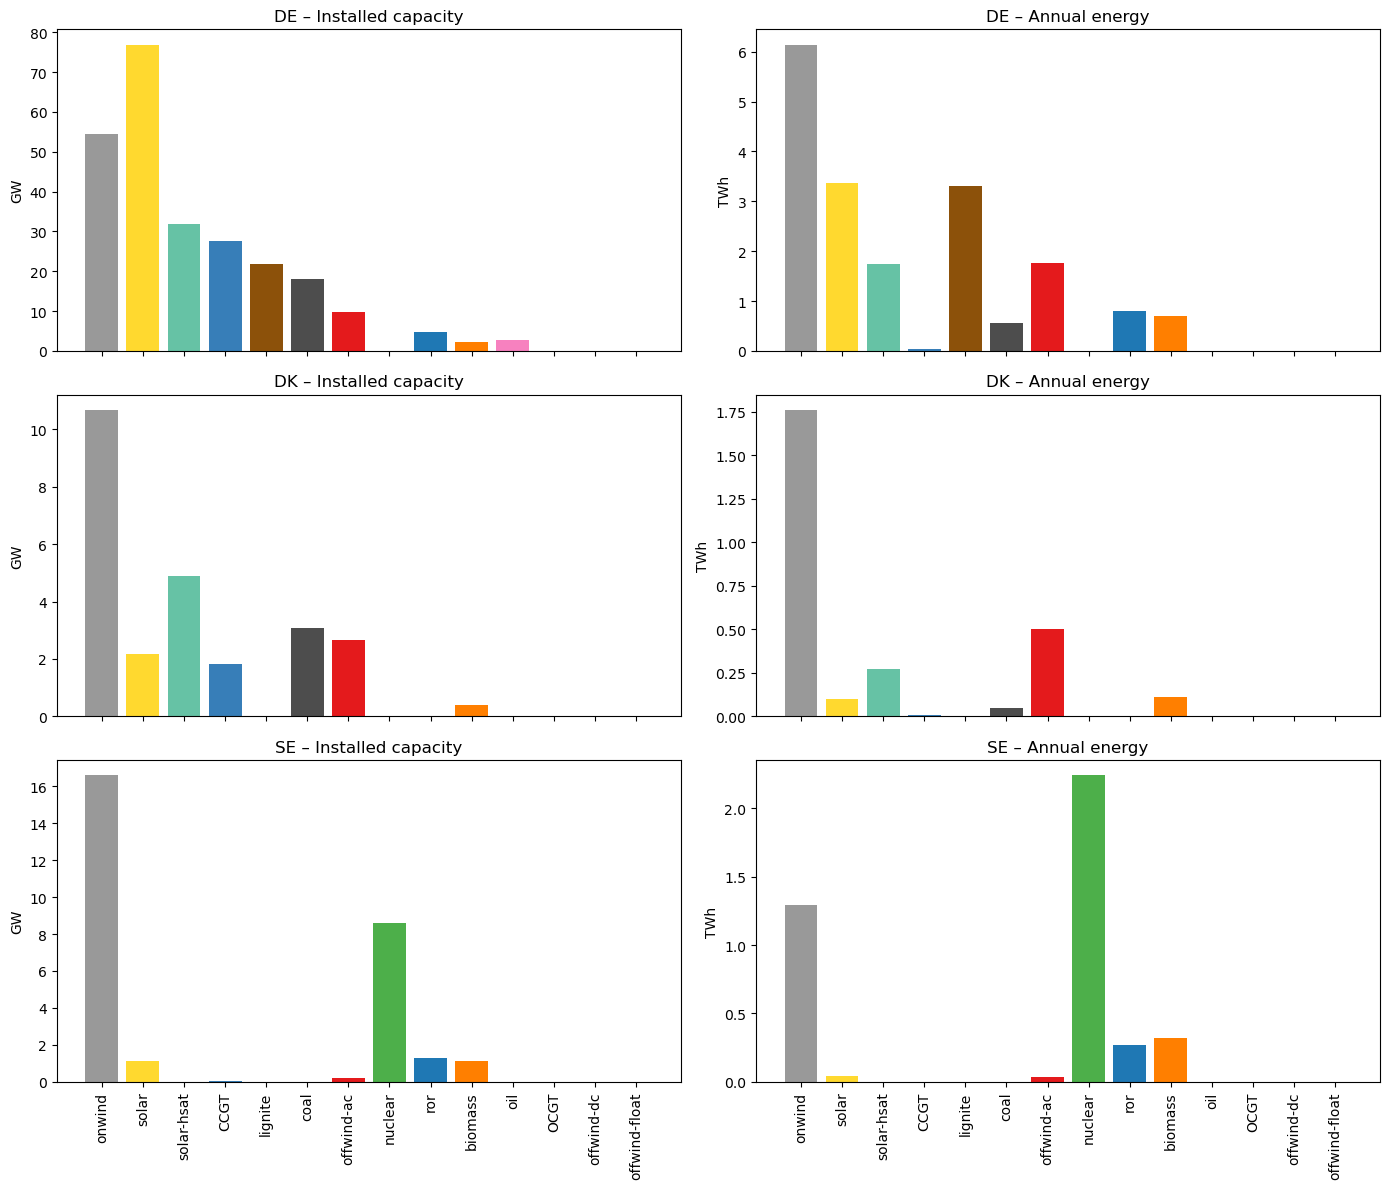

In [24]:
plot_capacity_vs_energy_by_country(
    n,
    tech_summary,
    tech_colors,
    mode="ALL"
    #countries=["SE", "DK"]
)

Capacity factors by technology (utilisation diagnostic)

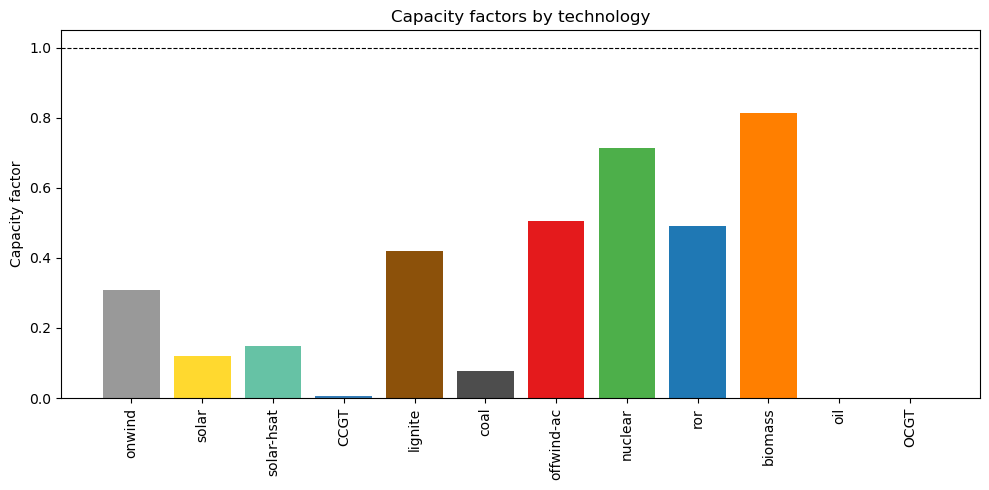

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    tech_summary.index,
    tech_summary["Capacity factor"],
    color=[tech_colors.get(t, "black") for t in tech_summary.index]
)

plt.axhline(1.0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Capacity factor")
plt.title("Capacity factors by technology")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Biomass & nuclear: near-continuous operation.
Offshore wind: high utilisation.
Solar & onshore wind: structurally limited. 
Gas, oil: insurance capacity, not energy suppliers

This justifies backup capacity existence.

Zonal capacity factor comparison across countries (SE vs DK vs DE)

In [20]:
# Merge generator info with dispatch
gen = n.generators.copy()
gen["country"] = n.buses.loc[gen.bus, "country"].values

dispatch = n.generators_t.p

zonal_cf = {}

for (country, carrier), idx in gen.groupby(["country", "carrier"]).groups.items():
    cap = gen.loc[idx, "p_nom_opt"].sum()
    if cap > 0:
        energy = dispatch[idx].sum().sum()
        zonal_cf[(country, carrier)] = energy / (cap * len(n.snapshots))

zonal_cf = (
    pd.Series(zonal_cf)
    .rename("capacity_factor")
    .reset_index()
    .rename(columns={"level_0": "country", "level_1": "carrier"})
)

zonal_cf

,country,carrier,capacity_factor
0,DE,CCGT,0.004171
1,DE,OCGT,0.000000
2,DE,biomass,0.831330
3,DE,coal,0.083498
4,DE,lignite,0.418751
5,DE,offwind-ac,0.503895
6,DE,oil,0.000000
7,DE,onwind,0.310070
8,DE,ror,0.467172
9,DE,solar,0.120068


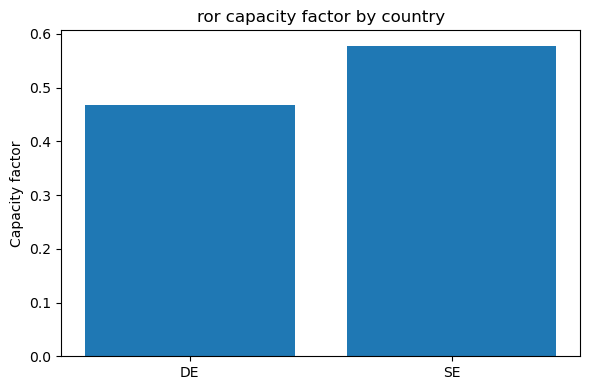

In [21]:
carrier = "ror"

subset = zonal_cf[zonal_cf.carrier == carrier]

plt.figure(figsize=(6,4))
plt.bar(
    subset.country,
    subset.capacity_factor,
    color=tech_colors.get(carrier, "black")
)

plt.ylabel("Capacity factor")
plt.title(f"{carrier} capacity factor by country")
plt.tight_layout()
plt.show()

Dispatch stack (time-domain intuition) using first week of February as representative week (important for later stochastic work):

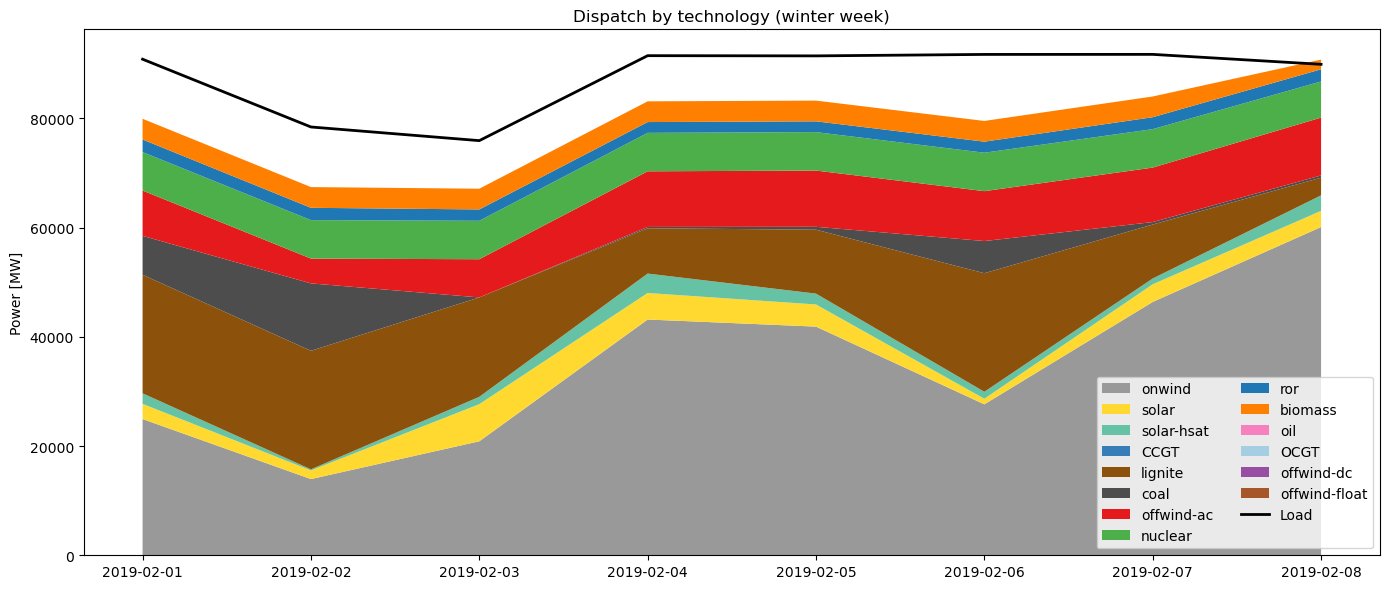

In [22]:
week = slice("2019-02-01", "2019-02-08")

dispatch = (
    n.generators_t.p.loc[week]
    .T
    .groupby(n.generators.carrier)
    .sum()
    .T
)

dispatch = dispatch[tech_summary.index]  # consistent ordering

plt.figure(figsize=(14,6))

plt.stackplot(
    dispatch.index,
    dispatch.T.values,
    labels=dispatch.columns,
    colors=[tech_colors.get(c, "black") for c in dispatch.columns]
)

# Load overlay
load = n.loads_t.p_set.loc[week].sum(axis=1)
plt.plot(load.index, load.values, color="black", linewidth=2, label="Load")

plt.legend(loc="lower right", ncol=2)
plt.ylabel("Power [MW]")
plt.title("Dispatch by technology (winter week)")
plt.tight_layout()
plt.show()

Seasonal 2×2 Dispatch Plot

In [23]:
seasons = {
    "Winter": slice("2019-02-01", "2019-02-08"),
    "Spring": slice("2019-05-01", "2019-05-08"),
    "Summer": slice("2019-08-01", "2019-08-08"),
    "Autumn": slice("2019-11-01", "2019-11-08"),
}

In [24]:
def plot_seasonal_dispatch_load_price(
    n,
    seasons,
    tech_summary,
    tech_colors,
    mode="COMBINED",          # "COMBINED" or "SELECT"
    countries=None            # e.g. ["SE"], ["SE", "DK"]
):
    """
    2x2 seasonal plot of:
    - stacked generation by technology
    - total electrical load (black line)
    - load-weighted average price (red dashed line)

    Works for COMBINED (all countries) or SELECT (subset of countries).
    """

    assert mode in ["COMBINED", "SELECT"]

    # -----------------------------
    # Generator → country mapping
    # -----------------------------
    gen = n.generators.copy()
    gen["country"] = n.buses.loc[gen.bus, "country"].values

    # -----------------------------
    # Load-carrying buses ONLY
    # -----------------------------
    load_buses = n.loads.bus.unique()

    # -----------------------------
    # Time series
    # -----------------------------
    dispatch_all = n.generators_t.p
    load_all = n.loads_t.p_set
    price_all = n.buses_t.marginal_price

    # -----------------------------
    # Aggregate loads to buses
    # -----------------------------
    bus_load = (
        load_all
        .T
        .groupby(n.loads.bus)
        .sum()
        .T
    )

    techs = tech_summary.index
    colors = [tech_colors.get(t, "black") for t in techs]

    # -----------------------------
    # Figure layout
    # -----------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    # -----------------------------
    # Loop over seasons
    # -----------------------------
    for ax, (season, week) in zip(axes, seasons.items()):

        # ---- Country selection ----
        if mode == "COMBINED":
            gen_idx = gen.index
            bus_idx = load_buses
            title_suffix = "All countries"

        else:  # SELECT
            assert countries is not None, "Provide countries for SELECT mode"

            gen_idx = gen.index[gen.country.isin(countries)]
            bus_idx = load_buses[
                n.buses.loc[load_buses, "country"].isin(countries)
            ]
            title_suffix = " + ".join(countries)

        # ---- Dispatch aggregation (future-proof) ----
        disp = (
            dispatch_all.loc[week, gen_idx]
            .T
            .groupby(gen.loc[gen_idx, "carrier"])
            .sum()
            .T
            .reindex(columns=techs, fill_value=0)
        )

        # ---- Total load ----
        load = bus_load.loc[week, bus_idx].sum(axis=1)

        # ---- Load-weighted average price ----
        prices_sel = price_all.loc[week, bus_idx]
        bus_load_sel = bus_load.loc[week, bus_idx]

        weighted_price = (
            (prices_sel * bus_load_sel).sum(axis=1)
            / bus_load_sel.sum(axis=1)
        )

        # ---- Plot stacked dispatch ----
        ax.stackplot(
            disp.index,
            disp.T.values,
            colors=colors
        )

        # ---- Load line ----
        ax.plot(
            load.index,
            load.values,
            color="black",
            lw=2,
            label="Load"
        )

        ax.set_ylabel("Power [MW]")
        ax.set_title(f"{season} – {title_suffix}")

        # ---- X-axis formatting (month + day only) ----
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

        # ---- Secondary axis for price ----
        ax2 = ax.twinx()
        ax2.plot(
            weighted_price.index,
            weighted_price.values,
            color="darkred",
            lw=2,
            linestyle="--",
            label="Price"
        )
        ax2.set_ylabel("Price [€/MWh]", color="darkred")
        ax2.tick_params(axis="y", labelcolor="darkred")

    # -----------------------------
    # Legend
    # -----------------------------
    axes[0].legend(
        list(techs) + ["Load", "Price"],
        loc="upper left",
        ncol=3
    )

    plt.tight_layout()
    plt.show()

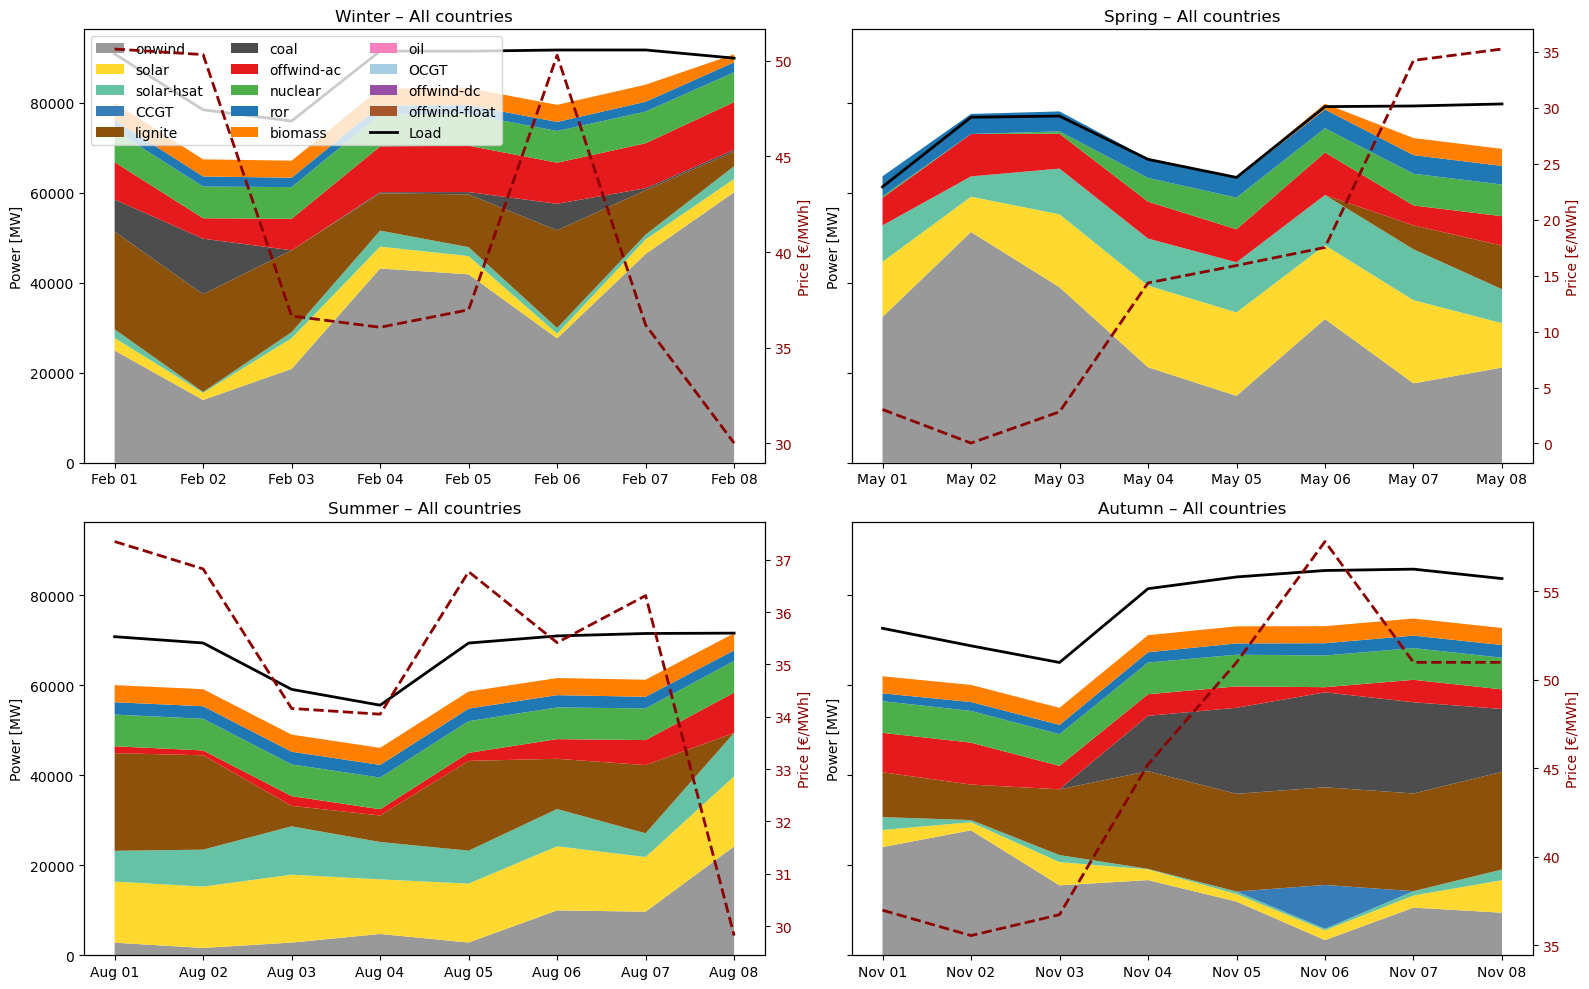

In [25]:
plot_seasonal_dispatch_load_price(
    n,
    seasons,
    tech_summary,
    tech_colors,
    mode="COMBINED"
)


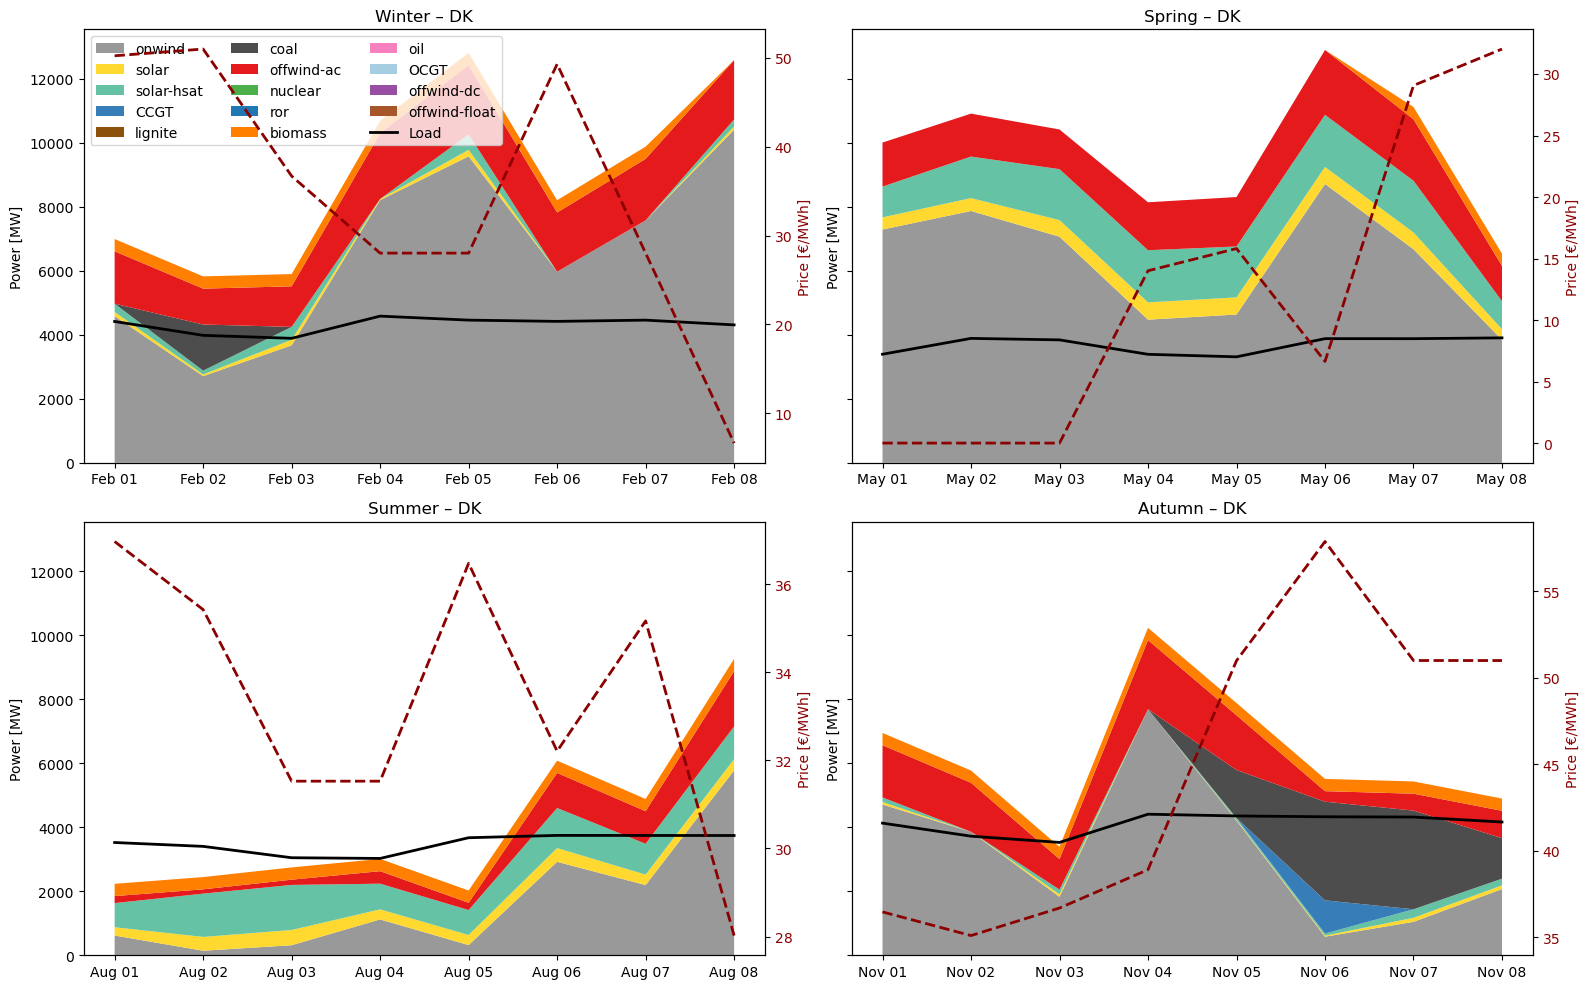

In [26]:
plot_seasonal_dispatch_load_price(
    n,
    seasons,
    tech_summary,
    tech_colors,
    mode="SELECT",
    countries=["DK"]
)


IMPLEMENT STOCHASTIC SCENARIOS 

In [27]:
scenarios = {
    "base":      {"p": 0.25, "load": 1.00, "wind": 1.00, "solar": 1.00},
    "hi_load":   {"p": 0.10, "load": 1.05, "wind": 1.00, "solar": 1.00},
    "lo_load":   {"p": 0.10, "load": 0.95, "wind": 1.00, "solar": 1.00},
    "lo_wind":   {"p": 0.10, "load": 1.00, "wind": 0.80, "solar": 1.00},
    "hi_wind":   {"p": 0.10, "load": 1.00, "wind": 1.20, "solar": 1.00},
    "lo_solar":  {"p": 0.10, "load": 1.00, "wind": 1.00, "solar": 0.80},
    "hi_solar":  {"p": 0.10, "load": 1.00, "wind": 1.00, "solar": 1.20},
    "stress":    {"p": 0.15, "load": 1.05, "wind": 0.80, "solar": 1.00},
}

The scenario probabilities form a probability mass function over a finite set of system states, explicitly assigning significant likelihood to unfavourable conditions such as low wind or high demand. As a result, the deterministic base case represents only a minority of plausible operating conditions. It is just like saying the future is uncertain, and planning must account for more than average conditions

In [28]:
WIND_CARRIERS  = {"onwind", "offwind-ac", "offwind-dc", "offwind-float"}
SOLAR_CARRIERS = {"solar", "solar-hsat"}

def make_scenario_network(n, load_mult=1.0, wind_mult=1.0, solar_mult=1.0):  #scenario multipliers
    ns = n.copy()

    # --- Load scaling --- networks can vary (some have no time series, or different components). The hasattr checks prevent crashes if those data aren’t present.
    if hasattr(ns, "loads_t") and hasattr(ns.loads_t, "p_set") and not ns.loads_t.p_set.empty:
        ns.loads_t.p_set = ns.loads_t.p_set * load_mult

    # --- Generator availability scaling via p_max_pu (not dispatch) ---
    if hasattr(ns, "generators_t") and hasattr(ns.generators_t, "p_max_pu") and not ns.generators_t.p_max_pu.empty:
        carriers = ns.generators.carrier

        wind_idx  = carriers[carriers.isin(WIND_CARRIERS)].index
        solar_idx = carriers[carriers.isin(SOLAR_CARRIERS)].index

        if len(wind_idx) > 0:
            ns.generators_t.p_max_pu.loc[:, wind_idx] = (
                ns.generators_t.p_max_pu.loc[:, wind_idx] * wind_mult
            ).clip(lower=0.0, upper=1.0)

        if len(solar_idx) > 0:
            ns.generators_t.p_max_pu.loc[:, solar_idx] = (
                ns.generators_t.p_max_pu.loc[:, solar_idx] * solar_mult
            ).clip(lower=0.0, upper=1.0)

    return ns

In [29]:
def summarize_results(ns, name):
    # Objective
    obj = getattr(ns, "objective", float("nan")) #This is the optimal value of the system cost function for that scenario

    # Load-weighted mean price (using correct bus-load logic, Aggregate load time series from “loads” to “buses”)
    load_buses = ns.loads.bus.unique()
    bus_load = (
        ns.loads_t.p_set.T.groupby(ns.loads.bus).sum().T
    )
    # Extract nodal prices at load buses and matching load weights
    prices = ns.buses_t.marginal_price.loc[:, load_buses] 
    weights = bus_load.loc[:, load_buses]
    
    # Compute load-weighted price time series, then summary stats
    avg_price = ((prices * weights).sum(axis=1) / weights.sum(axis=1)).mean()
    p95_price = ((prices * weights).sum(axis=1) / weights.sum(axis=1)).quantile(0.95)
    max_price = ((prices * weights).sum(axis=1) / weights.sum(axis=1)).max()

    # Generation by carrier (energy)
    gen_energy = ns.generators_t.p.sum(axis=0) #sum of time series dispatch: time × generators
    by_carrier = gen_energy.groupby(ns.generators.carrier).sum()  # Aggregate generator energy by carrier (technology) in MWh
    total_gen = by_carrier.sum()
    
    fossil = 0.0 #initialises an accumulator that is used to sum the total electricity generated by fossil-fuel technologies across all time steps.
    for c in ["coal", "lignite", "CCGT", "OCGT", "oil"]:
        if c in by_carrier.index:
            fossil += by_carrier.loc[c] #avoids accidental integer division. this is good numerical hygiene.

    fossil_share = float(fossil / total_gen) if total_gen > 0 else float("nan") #how much of the system’s electricity came from fossil fuels

    return {
        "scenario": name,
        "objective": obj,
        "avg_price_EUR_MWh": float(avg_price),
        "p95_price_EUR_MWh": float(p95_price),
        "max_price_EUR_MWh": float(max_price),
        "fossil_energy_share": fossil_share,
    }

In [ ]:
CACHE_DIR = Path("scenario_cache")
CACHE_DIR.mkdir(exist_ok=True)

#cache_file = CACHE_DIR / "stochastic_results.csv"
def scenario_hash(scenarios):
    s = json.dumps(scenarios, sort_keys=True)
    return hashlib.md5(s.encode()).hexdigest()

hash_id = scenario_hash(scenarios)
cache_file = CACHE_DIR / f"stochastic_results_{hash_id}.csv"

In [ ]:
def run_or_load_scenarios(
    n,
    scenarios,
    force_run=False,
    solver="highs" # or "gurobi", "cbc"?
):
    """
    Run stochastic scenarios or load cached results if available.
    """

    if cache_file.exists() and not force_run:
        print("✅ Loading cached scenario results")
        return pd.read_csv(cache_file)

    print("🔁 Running stochastic scenarios (this may take time)")
    results = []

    for sname, s in scenarios.items():
        print(f"  → Solving scenario: {sname}")

        ns = make_scenario_network(
            n,
            load_mult=s["load"],
            wind_mult=s["wind"],
            solar_mult=s["solar"],
        )

        # Solve with modern PyPSA API
        ns.optimize(solver_name=solver)

        row = summarize_results(ns, sname)
        row["prob"] = s["p"]
        row["load_mult"] = s["load"]
        row["wind_mult"] = s["wind"]
        row["solar_mult"] = s["solar"]

        results.append(row)

    results_df = pd.DataFrame(results).sort_values("scenario")

    # Save cache
    results_df.to_csv(cache_file, index=False)
    print(f"💾 Results cached to {cache_file}")

    return results_df


When should the scenarios be re-run? ie. set force_run=True only if one of these changes:

scenario definitions (probs (p), load/wind/solar multipliers)

network structure (capacities, topology)

solver formulation (eg. LP → MILP)

time resolution or snapshot selection

No need to re-run if: Plots change, compute new risk metrics or recompute expectations or CVaR

In [84]:
results_df = run_or_load_scenarios(
    n,
    scenarios,
    force_run=False,     # set True if scenarios are changed
    solver="highs"
)

results_df

✅ Loading cached scenario results


,scenario,objective,avg_price_EUR_MWh,p95_price_EUR_MWh,max_price_EUR_MWh,fossil_energy_share,prob,load_mult,wind_mult,solar_mult
0,base,5.517814e+09,30.814176,49.658619,57.433020,0.157006,0.25,1.00,1.0,1.0
1,hi_load,6.569055e+09,31.661516,51.380085,59.054087,0.149962,0.10,1.05,1.0,1.0
2,hi_solar,4.862990e+09,26.948902,44.716627,55.535964,0.157116,0.10,1.00,1.0,1.2
3,hi_wind,4.304107e+09,28.400458,47.615347,56.649533,0.156763,0.10,1.00,1.2,1.0
4,lo_load,4.497025e+09,29.907210,47.933521,56.417478,0.165121,0.10,0.95,1.0,1.0
5,lo_solar,6.230848e+09,35.140626,55.578868,59.700960,0.159028,0.10,1.00,1.0,0.8
6,lo_wind,7.004277e+09,34.406066,54.244554,59.192729,0.158613,0.10,1.00,0.8,1.0
7,stress,8.187491e+09,35.412561,56.277983,60.983047,0.153470,0.15,1.05,0.8,1.0


In [42]:
expected_cost = (results_df["objective"] * results_df["prob"]).sum()
expected_cost

5954407286.183618

In [43]:
expected_avg_price = (
    results_df["avg_price_EUR_MWh"] * results_df["prob"]
).sum()

expected_avg_price

31.661905868428008

In [44]:
expected_p95_price = (
    results_df["p95_price_EUR_MWh"] * results_df["prob"]
).sum()

expected_p95_price

51.00325250311002

In [45]:
expected_fossil_share = (
    results_df["fossil_energy_share"] * results_df["prob"]
).sum()

expected_fossil_share

0.1569323613861241

In [46]:
expected_summary = {
    "Expected system cost [€]": expected_cost,
    "Expected avg price [€/MWh]": expected_avg_price,
    "Expected P95 price [€/MWh]": expected_p95_price,
    "Expected fossil share": expected_fossil_share,
}

expected_summary


{'Expected system cost [€]': 5954407286.183618,
 'Expected avg price [€/MWh]': 31.661905868428008,
 'Expected P95 price [€/MWh]': 51.00325250311002,
 'Expected fossil share': 0.1569323613861241}

In [52]:
base_cost = results_df.loc[results_df["scenario"]=="base", "objective"].iloc[0]
expected_cost = (results_df["objective"] * results_df["prob"]).sum()

vss_proxy = expected_cost - base_cost
vss_proxy_pct = 100 * vss_proxy / base_cost

vss_proxy, vss_proxy_pct

(436593506.28277683, 7.912436405032551)

The probability-weighted expected outcomes indicate that deterministic baseline assumptions underestimate system cost by approximately (59.5 - 5.52/5.52) 8% and fail to capture elevated tail price risks. While average electricity prices increase only modestly when uncertainty is accounted for, the expected 95th-percentile price rises more substantially, indicating heightened exposure to extreme price events. In contrast, the fossil energy share remains relatively stable, suggesting that uncertainty primarily manifests through economic stress rather than a structural shift in the generation mix.

Using the deterministic base scenario as a single representation of future conditions underestimates the probability-weighted expected system cost by approximately €0.44 billion (≈7.9%). This indicates that uncertainty, particularly low-wind and stress conditions has a material impact on expected system performance and motivates stochastic evaluation (and potentially stochastic optimisation) approaches.

In [48]:
results_df["expected_cost_contribution"] = (
    results_df["objective"] * results_df["prob"]
)
results_df["cost_share_percent"] = (
    100 * results_df["expected_cost_contribution"]
    / results_df["expected_cost_contribution"].sum()
)

results_df[[
    "scenario",
    "prob",
    "objective",
    "cost_share_percent"
]]

,scenario,prob,objective,cost_share_percent
0,base,0.25,5.517814e+09,23.166931
1,hi_load,0.10,6.569055e+09,11.032256
6,hi_solar,0.10,4.862990e+09,8.167043
4,hi_wind,0.10,4.304107e+09,7.228439
2,lo_load,0.10,4.497025e+09,7.552431
5,lo_solar,0.10,6.230848e+09,10.464262
3,lo_wind,0.10,7.004277e+09,11.763182
7,stress,0.15,8.187491e+09,20.625456


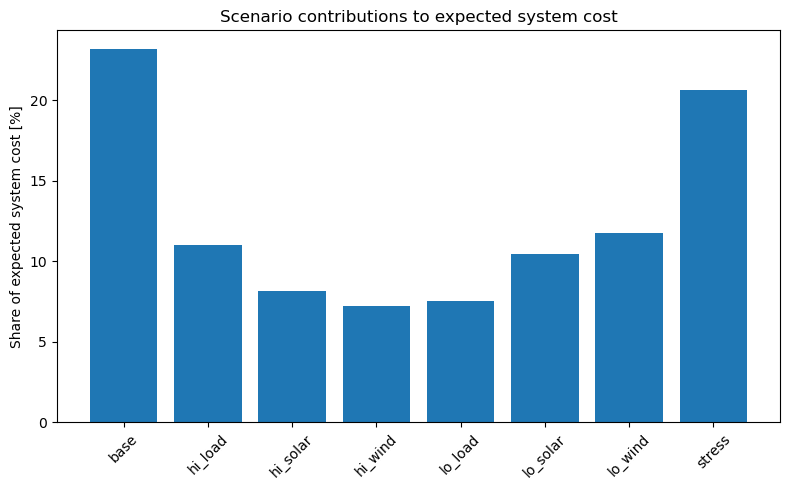

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    results_df["scenario"],
    results_df["cost_share_percent"]
)
plt.ylabel("Share of expected system cost [%]")
plt.title("Scenario contributions to expected system cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Decomposing the expected system cost into scenario contributions reveals a strong asymmetry in the impact of uncertainty. Although the base scenario has the highest individual probability, it accounts for only 23% of the expected cost. In contrast, low-wind and combined stress scenarios contribute disproportionately, together accounting for more than 30% of expected cost despite lower probabilities. This indicates that expected outcomes are dominated by adverse but plausible system states rather than average conditions, underscoring the limitations of deterministic planning approaches.

In [53]:
def var_cvar_discrete(values, probs, alpha=0.95):
    # sort by value
    order = np.argsort(values)
    v = np.array(values)[order]
    p = np.array(probs)[order]

    cdf = np.cumsum(p)
    # VaR = smallest value where CDF >= alpha
    var = v[np.searchsorted(cdf, alpha)]

    # CVaR = expected value in tail beyond VaR threshold
    tail_mask = v >= var
    tail_v = v[tail_mask]
    tail_p = p[tail_mask]
    cvar = (tail_v * tail_p).sum() / tail_p.sum()
    return var, cvar

costs = results_df["objective"].values
probs = results_df["prob"].values

var95, cvar95 = var_cvar_discrete(costs, probs, alpha=0.95)
var95, cvar95


(8187490878.3087845, 8187490878.3087845)

In [55]:
plot_df = results_df.copy()
plot_df = plot_df.sort_values("objective").reset_index(drop=True)

plot_df["cum_prob"] = plot_df["prob"].cumsum()
plot_df["in_cvar_tail"] = plot_df["objective"] >= var95

Now, how bad are bad scenarios? Let's look at the distribution of costs and identify the tail scenarios.

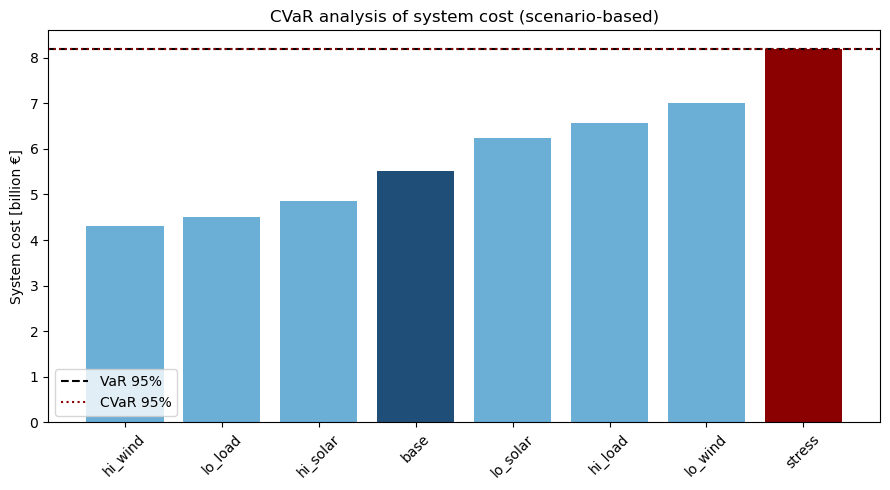

In [62]:
base_color = "#1f4e79"      # deep blue
normal_color = "#6baed6"   # light blue
tail_color = "darkred"

plt.figure(figsize=(9,5))

colors = []
for _, row in plot_df.iterrows():
    if row["scenario"] == "base":
        colors.append(base_color)
    elif row["in_cvar_tail"]:
        colors.append(tail_color)
    else:
        colors.append(normal_color)

plt.bar(
    plot_df["scenario"],
    plot_df["objective"] / 1e9,
    color=colors
)

plt.axhline(var95 / 1e9, color="black", linestyle="--", label="VaR 95%")
plt.axhline(cvar95 / 1e9, color="darkred", linestyle=":", label="CVaR 95%")

plt.ylabel("System cost [billion €]")
plt.title("CVaR analysis of system cost (scenario-based)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We have a risk-oriented view of system costs across different operational scenarios, highlighting how uncertainty in renewable variability translates into economic vulnerability. Under favourable conditions such as high wind or lower demand, the system operates efficiently with relatively low costs, reflecting the value of abundant renewable generation. However, as conditions deteriorate moving through reduced solar or wind availability and higher demand, thus the system becomes progressively more expensive, indicating increasing reliance on costly backup generation. The base case sits near the middle of this spectrum, suggesting that average conditions are not inherently problematic; rather, it is the tail of the distribution that drives risk. This is clearly illustrated by the stress scenario, which stands out as a significant outlier and dominates the upper end of costs. The VaR and CVaR thresholds reinforce this insight: while only a small fraction of scenarios exceed the VaR level, the CVaR shows that when extreme conditions occur, they lead to persistently high costs on average. In other words, the system is not just exposed to rare high-cost events, but those events are severe enough to materially influence overall economic performance. This underscores the importance of incorporating risk-aware metrics like CVaR in energy system planning, as traditional expected-value analysis may underestimate the impact of these extreme but consequential scenarios.

Lets identify both the average outcome and the worst-tail risk at the 95% level and plots these results as bar charts, showing the base scenario, the high-risk CVaR tail scenarios, and comparing normal expected performance against extreme-risk outcomes.

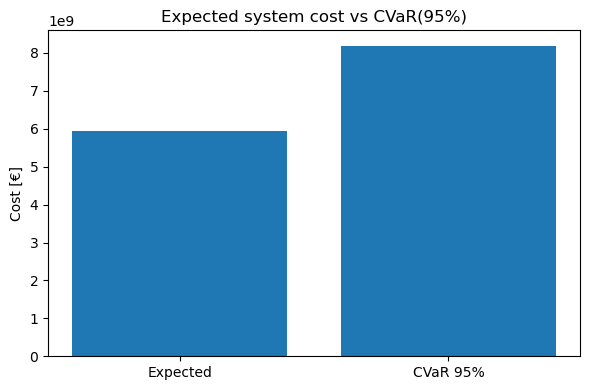

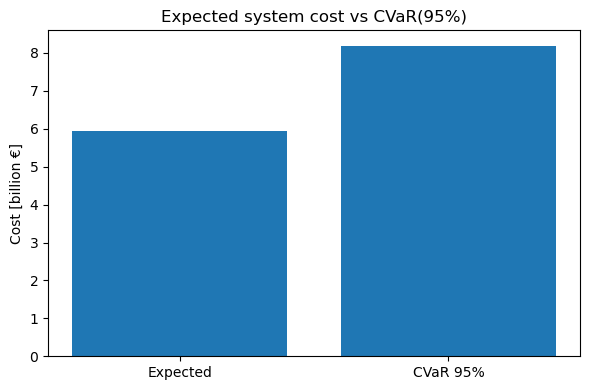

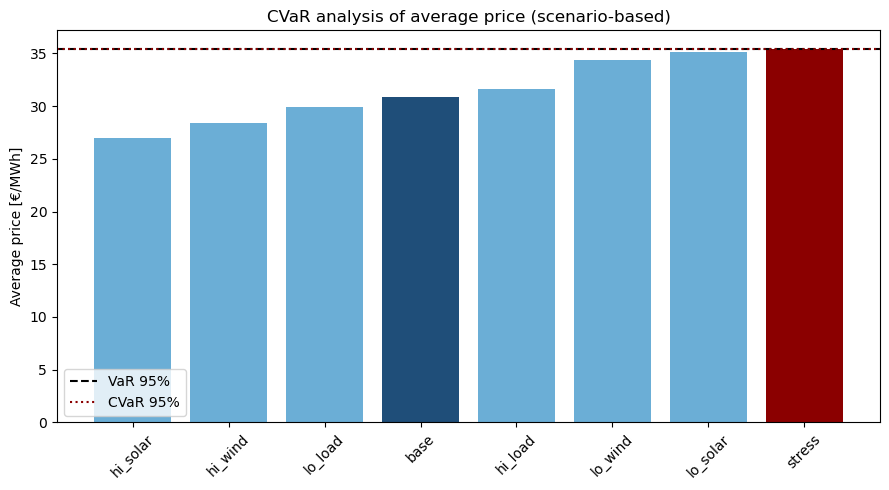

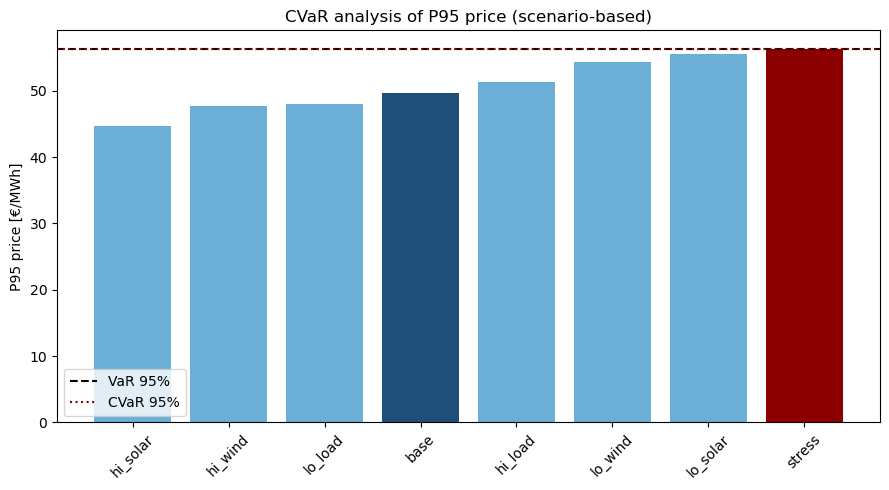

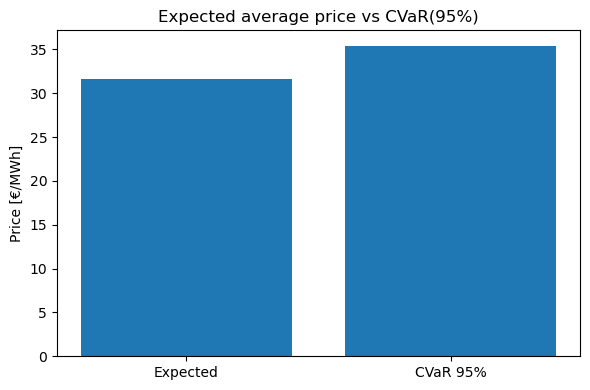

In [ ]:
def var_cvar_discrete(values, probs, alpha=0.95):
    """
    VaR/CVaR for discrete scenarios with probabilities.
    Returns (VaR, CVaR).
    """
    order = np.argsort(values)
    v = np.array(values)[order]
    p = np.array(probs)[order]

    cdf = np.cumsum(p)
    var = v[np.searchsorted(cdf, alpha)]

    tail = v >= var
    cvar = (v[tail] * p[tail]).sum() / p[tail].sum()
    return var, cvar


def plot_expected_vs_cvar(
    results_df,
    metric_col="objective",
    prob_col="prob",
    alpha=0.95,
    title=None,
    y_label=None
):
    """
    Side-by-side bars: Expected value vs CVaR_alpha for a given metric.
    """
    vals = results_df[metric_col].values
    probs = results_df[prob_col].values

    expected = (results_df[metric_col] * results_df[prob_col]).sum()
    var, cvar = var_cvar_discrete(vals, probs, alpha=alpha)

    plt.figure(figsize=(6,4))
    plt.bar(["Expected", f"CVaR {int(alpha*100)}%"], [expected, cvar])
    plt.title(title or f"Expected vs CVaR ({metric_col})")
    plt.ylabel(y_label or metric_col)
    plt.tight_layout()
    plt.show()

    return expected, var, cvar


def plot_cvar_bars(
    results_df,
    metric_col,
    prob_col="prob",
    alpha=0.95,
    scenario_col="scenario",
    base_scenario="base",
    title="",
    y_label="",
    base_color="#1f4e79",     # deep blue
    normal_color="#6baed6",   # light blue
    tail_color="darkred",
    unit_scale=1.0,
    unit_suffix=""
):
    """
    Scenario bar plot with VaR and CVaR lines + highlighting:
    - base scenario in deep blue
    - CVaR tail scenarios in dark red
    - others in light blue
    """
    df = results_df[[scenario_col, metric_col, prob_col]].copy()
    df = df.sort_values(metric_col).reset_index(drop=True)

    values = df[metric_col].values
    probs = df[prob_col].values
    var, cvar = var_cvar_discrete(values, probs, alpha=alpha)

    df["in_cvar_tail"] = df[metric_col] >= var

    colors = []
    for _, row in df.iterrows():
        if row[scenario_col] == base_scenario:
            colors.append(base_color)
        elif row["in_cvar_tail"]:
            colors.append(tail_color)
        else:
            colors.append(normal_color)

    plt.figure(figsize=(9,5))
    plt.bar(df[scenario_col], df[metric_col] / unit_scale, color=colors)

    plt.axhline(var / unit_scale, color="black", linestyle="--", label=f"VaR {int(alpha*100)}%")
    plt.axhline(cvar / unit_scale, color=tail_color, linestyle=":", label=f"CVaR {int(alpha*100)}%")

    plt.title(title)
    plt.ylabel(f"{y_label}{unit_suffix}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return var, cvar, df


# ----------------------------
# 1) Expected cost vs CVaR (side-by-side)
# ----------------------------
exp_cost, var_cost, cvar_cost = plot_expected_vs_cvar(
    results_df,
    metric_col="objective",
    alpha=0.95,
    title="Expected system cost vs CVaR(95%)",
    y_label="Cost [€]"
)

# If cost in billions on this plot:
plt.figure(figsize=(6,4))
plt.bar(["Expected", "CVaR 95%"], [exp_cost/1e9, cvar_cost/1e9])
plt.title("Expected system cost vs CVaR(95%)")
plt.ylabel("Cost [billion €]")
plt.tight_layout()
plt.show()


# ----------------------------
# 2) CVaR plot for PRICES (avg price)
# ----------------------------
var_p, cvar_p, _ = plot_cvar_bars(
    results_df,
    metric_col="avg_price_EUR_MWh",
    alpha=0.95,
    title="CVaR analysis of average price (scenario-based)",
    y_label="Average price [€/MWh]",
    unit_scale=1.0
)

# ----------------------------
# 3) CVaR plot for PRICES (P95 price) - tail-of-price metric
# ----------------------------
var_p95, cvar_p95, _ = plot_cvar_bars(
    results_df,
    metric_col="p95_price_EUR_MWh",
    alpha=0.95,
    title="CVaR analysis of P95 price (scenario-based)",
    y_label="P95 price [€/MWh]",
    unit_scale=1.0
)

# ----------------------------
# 4) Expected price vs CVaR side-by-side
# ----------------------------
exp_price, _, cvar_price = plot_expected_vs_cvar(
    results_df,
    metric_col="avg_price_EUR_MWh",
    alpha=0.95,
    title="Expected average price vs CVaR(95%)",
    y_label="Price [€/MWh]"
)


Across both cost and price metrics, the key message is that expected (average) outcomes significantly underestimate system risk. For system cost, the expected value is around €6 billion, while the CVaR rises to above €8 billion. This gap shows that although the system performs reasonably well under typical conditions, rare but adverse scenarios especially the stress case-drive disproportionately high costs. In other words, the economic risk is not evenly distributed; it is concentrated in a small number of extreme outcomes.

A similar pattern appears in electricity prices. The expected average price is around €31–32/MWh, but the CVaR rises to roughly €35/MWh, indicating that price spikes occur in the same high-risk scenarios that drive cost increases. The scenario-based CVaR plots reinforce this: most scenarios cluster within a moderate range, but a few particularly low renewable availability and the stress scenario sit in the tail beyond the VaR threshold, pulling the CVaR upward. This shows that system stress is tightly linked to renewable scarcity, which increases reliance on expensive backup generation.

Importantly, the base scenario is not the main driver of risk—it lies near the middle of the distribution. Instead, tail scenarios (low wind, low solar, high demand) dominate both cost and price risk. The P95 price plot further backs up this insight by showing that extreme price events (not just averages) are amplified under these conditions, a prove of potential market volatility and consumer impact.